In [1]:
import pandas as pd

In [14]:
import seaborn as sns

In [15]:
import matplotlib.pyplot as plt

In [57]:
from sklearn.feature_extraction import DictVectorizer

In [40]:
df = pd.read_parquet('data/green_tripdata_2021-01.parquet')

In [41]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,0.50,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,0.50,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,0.50,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,0.50,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.00,0.00,-0.5,0.00,0.00,None,-0.3,-52.80,3.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,2.75,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,0.00,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,2.75,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,2.75,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN


In [42]:
df = df[df.trip_type == 1].copy()

In [43]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

In [44]:
td = df.duration.iloc[0]

In [45]:
td.total_seconds() / 60

3.933333333333333

In [46]:
df.duration = df.duration.apply(lambda td:td.total_seconds() / 60)

In [47]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,...,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,...,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,...,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,...,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00,7.083333
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,...,-0.5,0.00,0.0,None,-0.3,-52.80,3.0,1.0,0.00,0.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40466,2,2021-01-31 23:34:34,2021-01-31 23:42:59,N,1.0,168,47,1.0,1.39,7.0,...,0.5,0.00,0.0,None,0.3,8.30,1.0,1.0,0.00,8.416667
40467,1,2021-01-31 23:13:36,2021-01-31 23:17:51,N,1.0,75,238,1.0,1.20,5.5,...,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00,4.250000
40468,2,2021-01-31 23:46:45,2021-01-31 23:57:08,N,1.0,41,263,1.0,2.70,10.5,...,0.5,0.00,0.0,None,0.3,14.55,1.0,1.0,2.75,10.383333
40469,1,2021-01-31 23:42:17,2021-01-31 23:48:19,N,1.0,75,75,1.0,1.10,6.0,...,0.5,1.80,0.0,None,0.3,9.10,1.0,1.0,0.00,6.033333


/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='duration', ylabel='Density'>

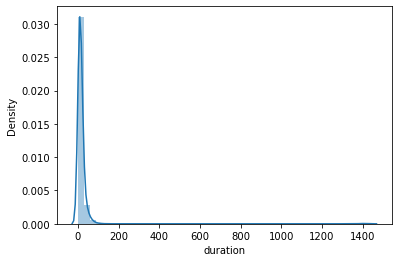

In [48]:
sns.distplot(df.duration)

In [49]:
df.duration.describe()
df.duration.describe(percentiles=[0.95, 0.98, 0.99])

count    39233.000000
mean        19.244240
std         79.147445
min          0.000000
50%         10.683333
95%         42.883333
98%         61.522667
99%         78.366667
max       1439.600000
Name: duration, dtype: float64

In [50]:
((df.duration >= 1) & (df.duration <=60)).mean()

0.9567201080722861

In [52]:
df = df[(df.duration >= 1) & (df.duration <=60)].copy()

In [53]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

In [54]:
df[categorical].dtypes

PULocationID    int64
DOLocationID    int64
dtype: object

In [55]:
df[categorical] = df[categorical].astype(str)

In [58]:
dv = DictVectorizer()